# ViT Benchmark

In [1]:
model_name = "ViT"

import torch
from torch import nn
from torchvision import models
import torch_mlir
import numpy as np
import iree.compiler
import iree.runtime

import warnings
warnings.filterwarnings("ignore")

from timeit import timeit as ti
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def compile_str(mlir):
    return iree.runtime.load_vm_flatbuffer(
        iree.compiler.compile_str(
            mlir, input_type="tosa", target_backends=["llvm-cpu"],
            extra_args=[
                "--iree-llvmcpu-target-cpu-features=host",
                "--iree-stream-partitioning-favor=max-concurrency",
                "--iree-flow-zero-fill-empty-tensors",
                "--iree-llvmcpu-fail-on-out-of-bounds-stack-allocation=0",
                "--iree-opt-const-eval",
                "--iree-opt-const-expr-hoisting",
                "--iree-opt-numeric-precision-reduction",
                "--iree-opt-strip-assertions"
            ]
        ),
        backend="llvm-cpu"
    )

def compile_file(filename):
    with open(filename) as f:
        return compile_str(f.read())
    
def get_dataframe(forward, backward, item):
    return pd.concat([
        pd.DataFrame({
            "time": forward,
            "pass": "Forward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": backward,
            "pass": "Backward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": forward + backward,
            "pass": "Full",
            "item": item
        }, index=[0]),
    ])

def timeit(stmt, n=100):
    return ti(stmt, globals=globals(), number=n) * 1000 / n

/root/anaconda3/envs/iree/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Prepare

In [2]:
help(models.vit_b_16)

Help on function vit_b_16 in module torchvision.models.vision_transformer:

vit_b_16(*, weights: Optional[torchvision.models.vision_transformer.ViT_B_16_Weights] = None, progress: bool = True, **kwargs: Any) -> torchvision.models.vision_transformer.VisionTransformer
    Constructs a vit_b_16 architecture from
    `An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale <https://arxiv.org/abs/2010.11929>`_.
    
    Args:
        weights (:class:`~torchvision.models.ViT_B_16_Weights`, optional): The pretrained
            weights to use. See :class:`~torchvision.models.ViT_B_16_Weights`
            below for more details and possible values. By default, no pre-trained weights are used.
        progress (bool, optional): If True, displays a progress bar of the download to stderr. Default is True.
        **kwargs: parameters passed to the ``torchvision.models.vision_transformer.VisionTransformer``
            base class. Please refer to the `source code
            <ht

In [4]:
MAGIC_NUM = 7777e-5

model = models.vit_b_16(pretrained=False).train(False)
model.load_state_dict({k: torch.ones_like(v) * MAGIC_NUM for k, v in model.state_dict().items()})

for module in model.modules():
    if isinstance(module, torch.nn.MultiheadAttention):
        module.need_weights = True

model = torch.compile(model, backend="inductor")

recompute, storeall = [
    compile_file(x) for x in ["recompute.mlir", "storeall.mlir"]
]

## Experimental

In [5]:
image = torch.randn(1, 3, 224, 224, requires_grad=True)
output = model(image)
grad = torch.randn_like(output)

image_np = image.detach().numpy()
grad_np = grad.numpy()

df = pd.DataFrame()

No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda'
[2023-07-26 03:45:50,580] torch.utils._sympy.value_ranges: [WARNING] unhandled ValueRange op __deepcopy__
[2023-07-26 03:45:50,583] torch.utils._sympy.value_ranges: [WARNING] unhandled ValueRange op __deepcopy__
[2023-07-26 03:45:50,638] torch.utils._sympy.value_ranges: [WARNING] unhandled ValueRange op __deepcopy__
[2023-07-26 03:45:50,639] torch.utils._sympy.value_ranges: [WARNING] unhandled ValueRange op __deepcopy__
[2023-07-26 03:45:50,945] torch.utils._sympy.value_ranges: [WARNING] unhandled ValueRange op __deepcopy__
[2023-07-26 03:45:50,947] torch.utils._sympy.value_ranges: [WARNING] unhandled ValueRange op __deepcopy__
[2023-07-26 03:45:51,104] torch.utils._sympy.value_ranges: [WARNING] unhandled ValueRange op __deepcopy__
[2023-07-26 03:45:51,105] torch.utils._sympy.value_ranges: [WARNING] unhandled ValueRange op __deepcopy__
[2023-07-26 03:45:51,250] torch.utils._sympy.value_ranges: [WARNING] unhandled ValueRange op

### PyTorch (Baseline)

In [6]:
baseline_f = timeit("model(image)")
baseline_b = timeit("torch.autograd.grad(output, [image], grad, retain_graph=True)")
df = pd.concat([df, get_dataframe(baseline_f, baseline_b, "Torch Dynamo")])

[2023-07-26 03:46:02,758] torch.utils._sympy.value_ranges: [WARNING] unhandled ValueRange op __deepcopy__
[2023-07-26 03:46:02,759] torch.utils._sympy.value_ranges: [WARNING] unhandled ValueRange op __deepcopy__
[2023-07-26 03:46:02,802] torch.utils._sympy.value_ranges: [WARNING] unhandled ValueRange op __deepcopy__
[2023-07-26 03:46:02,803] torch.utils._sympy.value_ranges: [WARNING] unhandled ValueRange op __deepcopy__
[2023-07-26 03:46:02,845] torch.utils._sympy.value_ranges: [WARNING] unhandled ValueRange op __deepcopy__
[2023-07-26 03:46:02,846] torch.utils._sympy.value_ranges: [WARNING] unhandled ValueRange op __deepcopy__
[2023-07-26 03:46:02,890] torch.utils._sympy.value_ranges: [WARNING] unhandled ValueRange op __deepcopy__
[2023-07-26 03:46:02,890] torch.utils._sympy.value_ranges: [WARNING] unhandled ValueRange op __deepcopy__
[2023-07-26 03:46:03,002] torch.utils._sympy.value_ranges: [WARNING] unhandled ValueRange op __deepcopy__
[2023-07-26 03:46:03,002] torch.utils._sympy.v

### Nabla without Optim

In [7]:
f = timeit("recompute.forward(image_np)")
b = timeit("recompute.dforward(grad_np)")
df = pd.concat([df, get_dataframe(f, b, "Nabla")])

### Nabla with Optim

In [8]:
f = timeit("storeall.forward(image_np)")
b = timeit("storeall.dforward(grad_np)")
df = pd.concat([df, get_dataframe(f, b, "Nabla Store-All")])

# f = timeit("storeall_fused.forward(image_np)")
# b = timeit("storeall_fused.dforward(grad_np)")
# df = pd.concat([df, get_dataframe(f, b, "Nabla Store-All Fused")])

## Result

In [9]:
# df.to_csv(f"{model_name}-time.csv")
df.style.hide(axis="index")

time,pass,item
74.319071,Forward,Torch Dynamo
193.846077,Backward,Torch Dynamo
268.165148,Full,Torch Dynamo
232.941662,Forward,Nabla
634.414004,Backward,Nabla
867.355665,Full,Nabla
268.756154,Forward,Nabla Store-All
314.008083,Backward,Nabla Store-All
582.764237,Full,Nabla Store-All


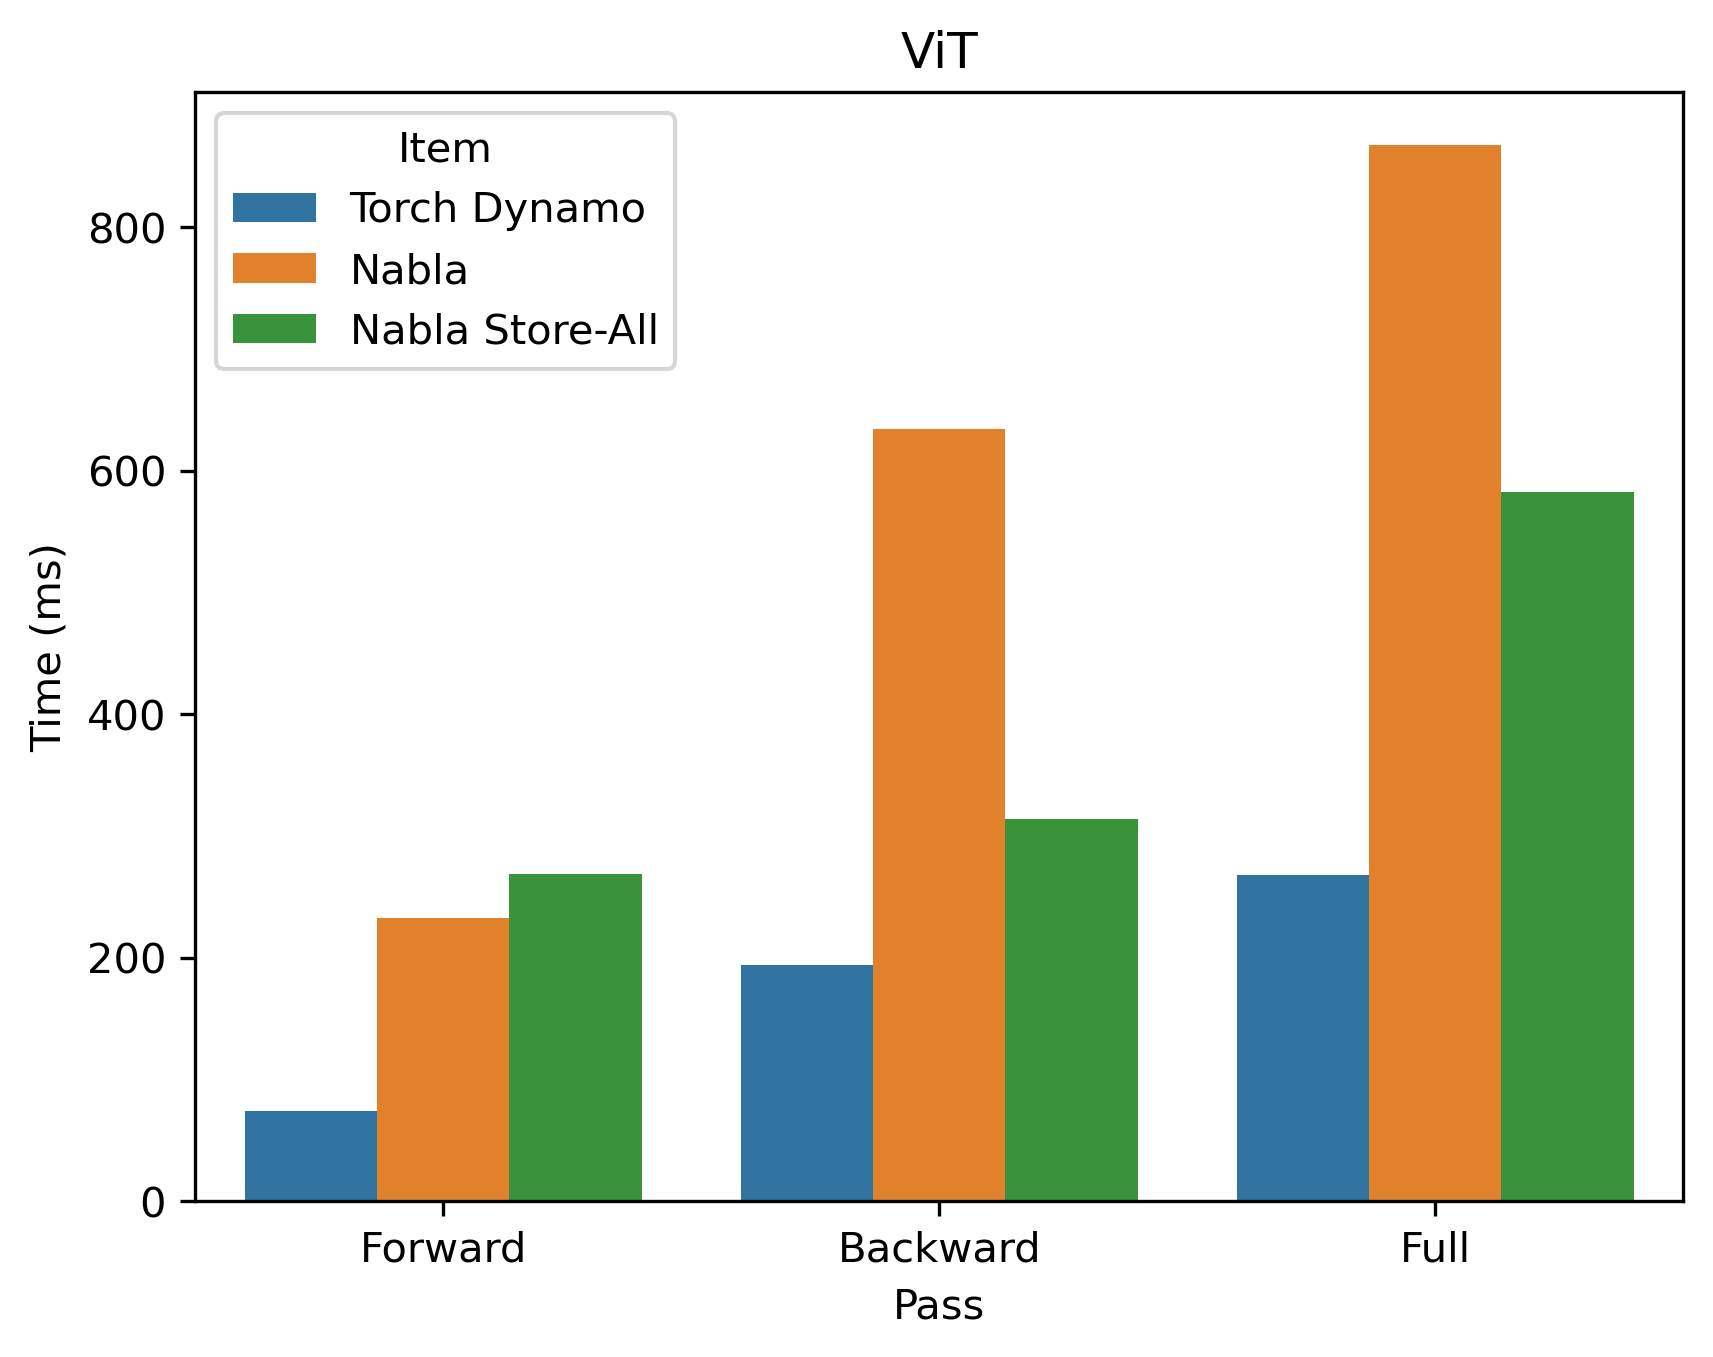

In [10]:
plt.rcParams["figure.dpi"] = 300

sns.barplot(df, x="pass", y="time", hue="item")
plt.xlabel("Pass")
plt.ylabel("Time (ms)")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-time.png")

In [11]:
forward = df[df["pass"] == "Forward"]
forward["acceleration"] = baseline_f / forward["time"]
forward

,time,pass,item,acceleration
0,74.319071,Forward,Torch Dynamo,1.000000
0,232.941662,Forward,Nabla,0.319046
0,268.756154,Forward,Nabla Store-All,0.276530


In [12]:
backward = df[df["pass"] == "Backward"]
backward["acceleration"] = baseline_b / backward["time"]
backward

,time,pass,item,acceleration
0,193.846077,Backward,Torch Dynamo,1.000000
0,634.414004,Backward,Nabla,0.305551
0,314.008083,Backward,Nabla Store-All,0.617328


In [13]:
full = df[df["pass"] == "Full"]
full["acceleration"] = (baseline_b + baseline_f) / full["time"]
full

,time,pass,item,acceleration
0,268.165148,Full,Torch Dynamo,1.000000
0,867.355665,Full,Nabla,0.309176
0,582.764237,Full,Nabla Store-All,0.460161


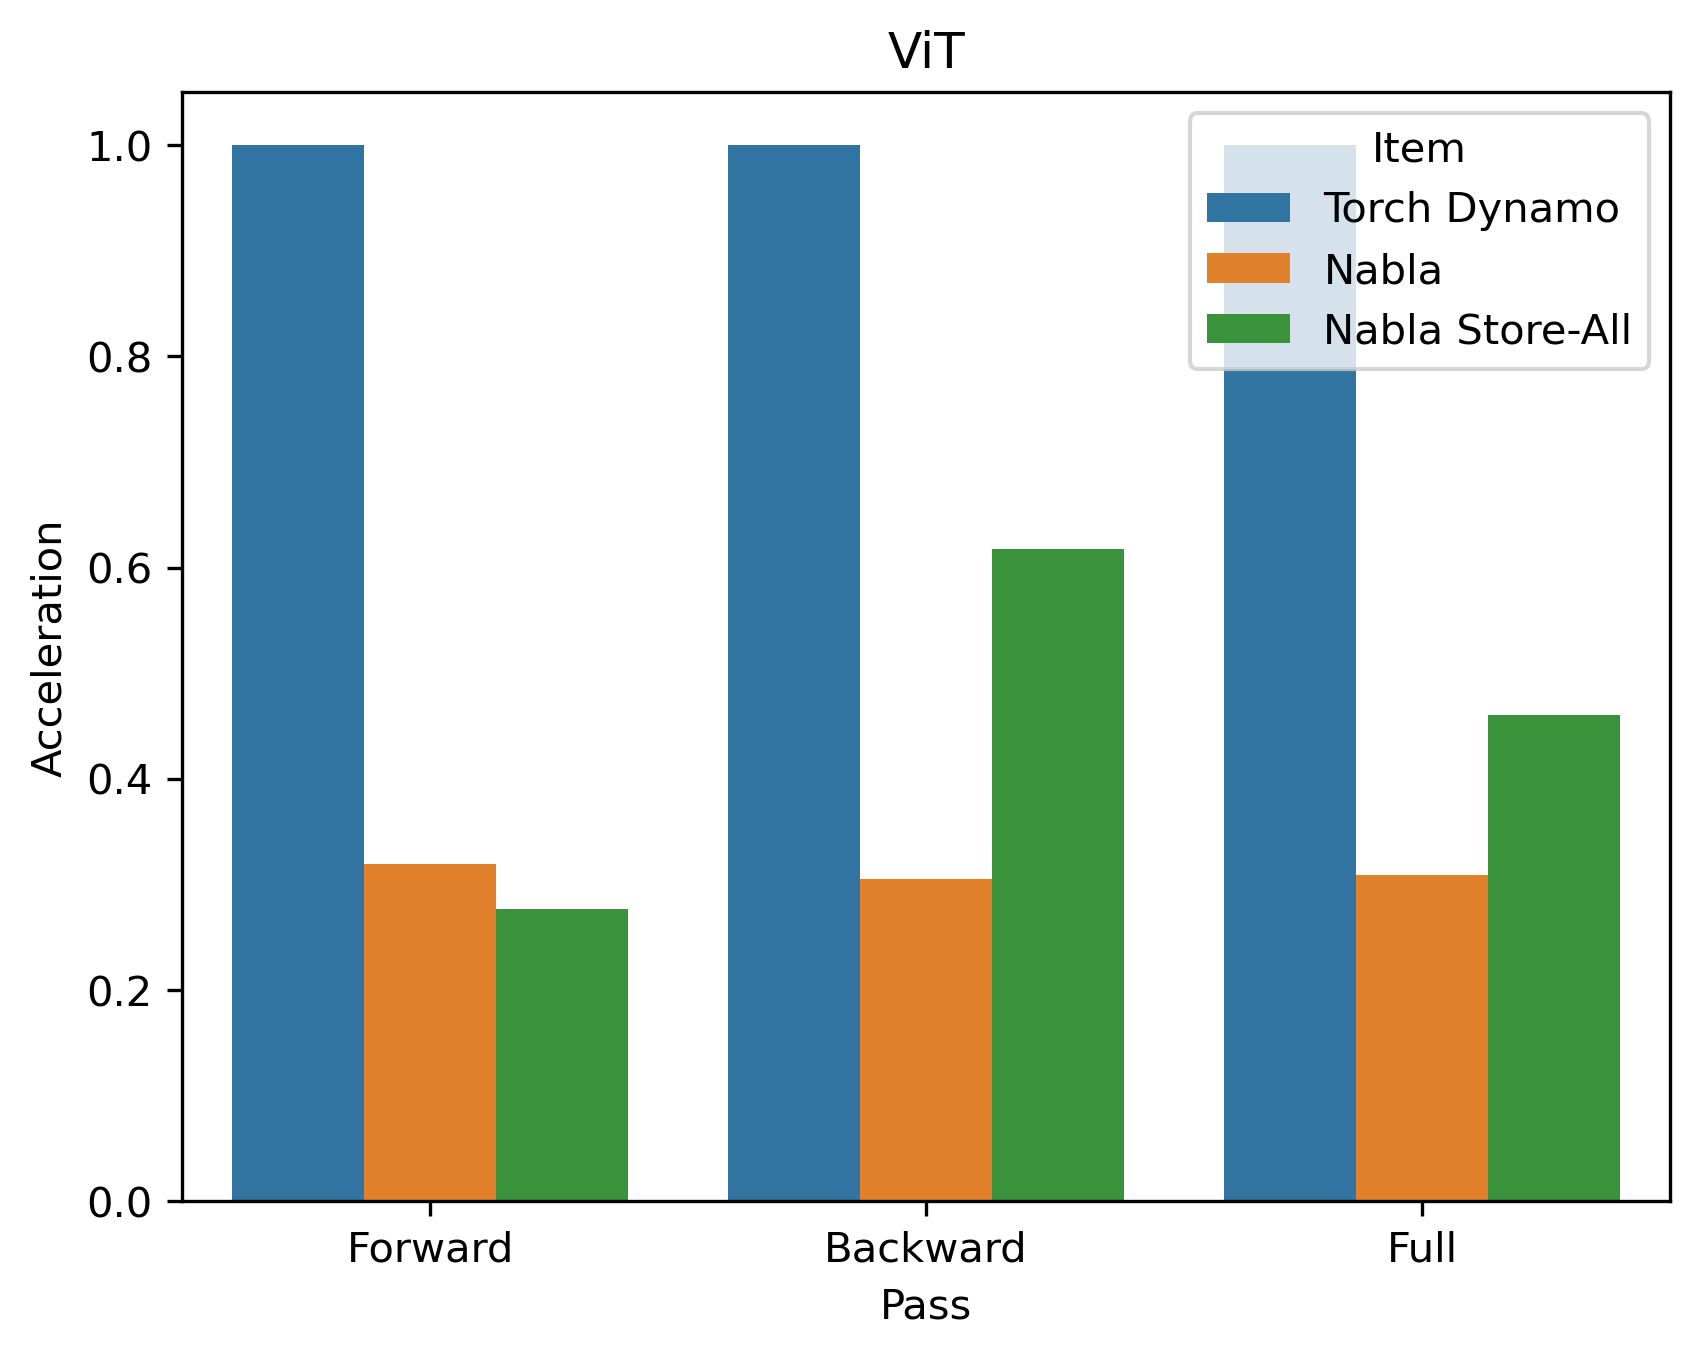

In [14]:
df = pd.concat([forward, backward, full])
# df.to_csv(f"{model_name}-acceleration.csv")

sns.barplot(df, x="pass", y="acceleration", hue="item")
plt.xlabel("Pass")
plt.ylabel("Acceleration")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-acceleration.png")